In [54]:
pip install google-cloud-storage

  Using cached google_auth-2.38.0-py2.py3-none-any.whl.metadata (4.8 kB)
  Using cached google_resumable_media-2.7.2-py2.py3-none-any.whl.metadata (2.2 kB)
  Using cached pyasn1_modules-0.4.1-py3-none-any.whl.metadata (3.5 kB)
  Using cached rsa-4.9-py3-none-any.whl.metadata (4.2 kB)
  Using cached pyasn1-0.6.1-py3-none-any.whl.metadata (8.4 kB)
Using cached google_auth-2.38.0-py2.py3-none-any.whl (210 kB)
Using cached google_resumable_media-2.7.2-py2.py3-none-any.whl (81 kB)
Using cached pyasn1_modules-0.4.1-py3-none-any.whl (181 kB)
Using cached rsa-4.9-py3-none-any.whl (34 kB)
Using cached pyasn1-0.6.1-py3-none-any.whl (83 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import osmnx as ox
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from shapely.ops import nearest_points
import pyproj
import math
from google.cloud import storage


In [30]:
# Define the latitude and longitude of the center point
latitude = 30.280929678710276
longitude = -97.75218815500368

# Define the radius in meters (25 km = 25000 meters)
radius = 25000

# Define amenities of interest
amenities_of_interest = {
    # food
    'cafe': ['coffee', 'green'],
    'bar': ['beer', 'green'],
    'restaurant': ['cutlery', 'green'],
    'pub': ['beer', 'green'],

    # social buildings
    'social_centre': ['institution', 'orange'],
    'library': ['book', 'orange'],
    'marketplace': ['shopping-cart', 'green'],
    'events_venue': ['institution', 'orange'],
    'exhibition_centre': ['institution', 'lightgrey'],
    'place_of_worship': ['institution', 'orange'],

    # places to chill
    'park': ['tree', 'green'],
    'music_venue': ['music', 'red'],
    'cinema': ['film', 'red'],
    'theatre': ['film', 'red']
}

# Define amenities of interest
amenities = list(amenities_of_interest.keys())
amenity_tags = {'amenity': amenities}

# Query the POIs within the specified radius
pois = ox.features.features_from_point((latitude, longitude), tags=amenity_tags, dist=radius)

# Filter the POIs to include only the amenities of interest
filtered_pois = pois[pois['amenity'].isin(amenities)]

# Create a new DataFrame with selected columns
columns_to_keep = ['amenity', 'name', 'geometry']  # Add other columns if needed
filtered_pois_df = filtered_pois[columns_to_keep]

# Add a column for the icon and color based on the amenities_of_interest dictionary
filtered_pois_df['icon'] = filtered_pois_df['amenity'].apply(lambda x: amenities_of_interest[x][0])
filtered_pois_df['color'] = filtered_pois_df['amenity'].apply(lambda x: amenities_of_interest[x][1])


c:\Users\Martin\AppData\Local\Programs\Python\Python312\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\Martin\AppData\Local\Programs\Python\Python312\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


## Data Transformation

In [31]:
unique_bus_stops = pd.read_csv("bus_stop_lat_lon.csv")
unique_bus_stops

,trip_id,arrival_time,departure_time,stop_id,stop_sequence,pickup_type,drop_off_type,shape_dist_traveled,timepoint,direction_id,stop_name,stop_lat,stop_lon
0,2729133_3220,04:58:00,04:58:00,5263,1,0,0,0.0000,1,1,200 Turk/Cullen,30.163367,-97.791351
1,2729133_3220,04:59:41,04:59:41,6479,2,0,0,0.4377,0,1,305 Slaughter/Alice Mae,30.167797,-97.793350
2,2729133_3220,05:00:27,05:00:27,5968,3,0,0,0.6388,0,1,324 Slaughter/Francia,30.169519,-97.795847
3,2729133_3220,05:01:43,05:01:43,6407,4,0,0,0.9725,0,1,603 Slaughter/1st,30.172829,-97.799722
4,2729133_3220,05:02:55,05:02:55,5416,5,0,0,1.2864,0,1,Slaughter/Simonetti,30.174173,-97.804467
...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,2729077_3326,06:28:41,06:28:41,3767,90,0,0,22.0309,0,0,815 Slaughter/Palace,30.173859,-97.805997
185,2729077_3326,06:30:20,06:30:20,5999,91,0,0,22.5106,0,0,509 Slaughter/1st,30.171795,-97.798989
186,2729077_3326,06:31:19,06:31:19,5380,92,0,0,22.7985,0,0,404 Slaughter/Francia,30.168969,-97.795672
187,2729077_3326,06:32:03,06:32:03,5623,93,0,0,23.0095,0,0,236 Slaughter/Alice Mae,30.167354,-97.792824


In [32]:
# Remove rows where the 'name' column is NaN
filtered_pois_df = filtered_pois_df.dropna(subset=['name','amenity'])
filtered_pois_df

amenity                               name  \
element id                                                                
node    336605818                bar                  The Elephant Room   
        338450996            theatre                The Hideout Theater   
        338450997               cafe                          Starbucks   
        338451013               cafe                          Starbucks   
        355352958   place_of_worship                    San Jose Church   
...                              ...                                ...   
way     1356339730        restaurant                               Komé   
        1359407886           theatre          Skyline Park Amphitheater   
        1361050951        restaurant          Flores Mexican Restaurant   
        1361786738  place_of_worship   Oak Hill United Methodist Church   
        1362339086        restaurant  J Carver’s Oyster Bar & Chophouse   

                                                             geometry  \
element id                                                              
node    336605818                           POINT (-97.7435 30.26562)   
        338450996                          POINT (-97.74223 30.26857)   
        338450997                          POINT (-97.74297 30.26827)   
        338451013                          POINT (-97.74118 30.27188)   
        355352958                          POINT (-97.76334 30.24201)   
...                                                               ...   
way     1356339730  POLYGON ((-97.71458 30.31413, -97.71464 30.313...   
        1359407886  POLYGON ((-97.71588 30.15193, -97.7159 30.1517...   
        1361050951  POLYGON ((-97.8429 30.2232, -97.84296 30.22297...   
        1361786738  POLYGON ((-97.88567 30.22745, -97.8854 30.2273...   
        1362339086  POLYGON ((-97.74951 30.26963, -97.74957 30.269...   

                           icon   color  
element id                               
node    336605818          beer   green  
        338450996          film     red  
        338450997        coffee   green  
        338451013        coffee   green  
        355352958   institution  orange  
...                         ...     ...  
way     1356339730      cutlery   green  
        1359407886         film     red  
        1361050951      cutlery   green  
        1361786738  institution  orange  
        1362339086      cutlery   green  

[2492 rows x 5 columns]

In [ ]:
# Step 1: Add a geometry column to the bus stop DataFrame
unique_bus_stops['geometry'] = unique_bus_stops.apply(lambda row: Point(row['stop_lon'], row['stop_lat']), axis=1)

# Step 2: Convert both DataFrames to GeoDataFrames
# Set the CRS to WGS84 (EPSG:4326) for latitude/longitude
bus_stops_gdf = gpd.GeoDataFrame(unique_bus_stops, geometry='geometry', crs='EPSG:4326')
pois_gdf = gpd.GeoDataFrame(filtered_pois_df, geometry='geometry', crs='EPSG:4326')

# Separate points and polygons
points_gdf = pois_gdf[pois_gdf.geometry.type == 'Point']
polygons_gdf = pois_gdf[pois_gdf.geometry.type == 'Polygon']

# Step 3: Create a copy for buffered bus stops
bus_stops_buffered_gdf = bus_stops_gdf.copy()

# Step 4: Calculate buffer distance in degrees
def meters_to_degrees(meters, latitude):
    return meters / (111320 * math.cos(math.radians(latitude)))

buffer_distance_degrees = meters_to_degrees(500, 30.26562)  # 500 meters at latitude 30.26562

# Step 5: Apply buffer to create circular areas around bus stops
bus_stops_buffered_gdf['geometry'] = bus_stops_buffered_gdf.geometry.buffer(buffer_distance_degrees)

# Step 6: Perform a spatial join to find POIs within the buffered area
pois_within_500m_points = gpd.sjoin(points_gdf,bus_stops_buffered_gdf,how='inner',predicate='within')
pois_within_500m_poly = gpd.sjoin(polygons_gdf, bus_stops_buffered_gdf, how='inner', predicate='intersects')

# Calculate for centroid
pois_within_500m_poly['geometry'] = pois_within_500m_poly['geometry'].centroid

combined_poi = pd.concat([pois_within_500m_poly, pois_within_500m_points], ignore_index=True)

C:\Users\Martin\AppData\Local\Temp\ipykernel_29052\3255159779.py:27: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bus_stops_buffered_gdf['geometry'] = bus_stops_buffered_gdf.geometry.buffer(buffer_distance_degrees)
C:\Users\Martin\AppData\Local\Temp\ipykernel_29052\3255159779.py:34: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pois_within_500m_poly['geometry'] = pois_within_500m_poly['geometry'].centroid


In [29]:
pois_gdf

amenity                               name  \
element id                                                                
node    336605818                bar                  The Elephant Room   
        338450996            theatre                The Hideout Theater   
        338450997               cafe                          Starbucks   
        338451013               cafe                          Starbucks   
        355352958   place_of_worship                    San Jose Church   
...                              ...                                ...   
way     1356339730        restaurant                               Komé   
        1359407886           theatre          Skyline Park Amphitheater   
        1361050951        restaurant          Flores Mexican Restaurant   
        1361786738  place_of_worship   Oak Hill United Methodist Church   
        1362339086        restaurant  J Carver’s Oyster Bar & Chophouse   

                                                             geometry  \
element id                                                              
node    336605818                           POINT (-97.7435 30.26562)   
        338450996                          POINT (-97.74223 30.26857)   
        338450997                          POINT (-97.74297 30.26827)   
        338451013                          POINT (-97.74118 30.27188)   
        355352958                          POINT (-97.76334 30.24201)   
...                                                               ...   
way     1356339730  POLYGON ((-97.71458 30.31413, -97.71464 30.313...   
        1359407886  POLYGON ((-97.71588 30.15193, -97.7159 30.1517...   
        1361050951  POLYGON ((-97.8429 30.2232, -97.84296 30.22297...   
        1361786738  POLYGON ((-97.88567 30.22745, -97.8854 30.2273...   
        1362339086  POLYGON ((-97.74951 30.26963, -97.74957 30.269...   

                           icon   color  
element id                               
node    336605818          beer   green  
        338450996          film     red  
        338450997        coffee   green  
        338451013        coffee   green  
        355352958   institution  orange  
...                         ...     ...  
way     1356339730      cutlery   green  
        1359407886         film     red  
        1361050951      cutlery   green  
        1361786738  institution  orange  
        1362339086      cutlery   green  

[2492 rows x 5 columns]

In [35]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lon1, lat1, lon2, lat2):
    # Convert degrees to radians
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    
    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    distance = 6371 * c * 1000  # Earth radius in km, convert to meters
    return distance

In [36]:
# Extract coordinates from geometry and stop_lat/stop_lon
combined_poi['distance'] = combined_poi.apply(
    lambda row: haversine(
        row.geometry.x, row.geometry.y,  # POI coordinates (lon, lat)
        row['stop_lon'], row['stop_lat']  # Bus stop coordinates
    ),
    axis=1
)

# Sort by distance (ascending) to prioritize shortest distances
combined_poi = combined_poi.sort_values('distance')

# Drop duplicates, keeping the closest POI per geometry
dedup_poi = combined_poi.drop_duplicates(subset=['geometry'], keep='first')

In [37]:
dedup_poi

,amenity,name,geometry,icon,color,index_right,trip_id,arrival_time,departure_time,stop_id,stop_sequence,pickup_type,drop_off_type,shape_dist_traveled,timepoint,direction_id,stop_name,stop_lat,stop_lon,distance
604,bar,Corner Bar,POINT (-97.76688 30.24944),beer,green,37,2729133_3220,05:31:21,05:31:21,4072,38,0,0,9.3523,0,1,1901 Lamar/Mary,30.249560,-97.767001,17.504854
241,restaurant,Kerbey Lane Cafe,POINT (-97.74152 30.29121),cutlery,green,136,2729077_3326,05:42:59,05:42:59,5863,42,0,0,9.7403,0,0,UT Dean Keeton Station (SB),30.291145,-97.741349,18.006790
2631,restaurant,Pizzeria Sportiva,POINT (-97.76429 30.25252),cutlery,green,149,2729077_3326,06:02:21,06:02:21,722,55,0,0,13.6943,0,0,1414 Lamar/Collier/SB,30.252465,-97.764114,18.127215
1774,restaurant,It's Italian Cucina,POINT (-97.76426 30.25258),cutlery,green,149,2729077_3326,06:02:21,06:02:21,722,55,0,0,13.6943,0,0,1414 Lamar/Collier/SB,30.252465,-97.764114,18.493847
138,restaurant,Bob's Steak & Chop House,POINT (-97.74592 30.26609),cutlery,green,44,2729133_3220,05:42:04,05:42:04,5868,45,0,0,11.5650,0,1,Republic Square Station (NB),30.266218,-97.746056,19.066444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2193,restaurant,Muse Fusion + Sushi,POINT (-97.79218 30.23366),cutlery,green,159,2729077_3326,06:10:21,06:10:21,733,65,0,0,16.0739,0,0,4308 Menchaca/Ben White,30.230504,-97.788112,525.247294
1347,restaurant,Thai Fresh,POINT (-97.76171 30.24794),cutlery,green,38,2729133_3220,05:32:17,05:32:17,776,39,0,0,9.6288,0,1,1458 Lamar/Collier,30.252289,-97.763972,529.640800
1736,restaurant,Vino Vino,POINT (-97.73532 30.30697),cutlery,green,55,2729133_3220,05:58:09,05:58:09,5350,56,0,0,14.4968,0,1,38th/Guadalupe,30.303402,-97.739012,532.094114
283,place_of_worship,Saint Davids Episcopal Church,POINT (-97.73938 30.26846),institution,orange,45,2729133_3220,05:44:04,05:44:04,2606,46,0,0,11.8831,0,1,Austin History Center Station (NB),30.270420,-97.744440,532.507631


In [24]:
# Step 5: Perform a spatial join to find POIs within the buffered area
pois_within_500m = gpd.sjoin(bus_stops_buffered_gdf, points_gdf, how='inner', predicate='intersects')

pois_within_500m 

,trip_id,arrival_time,departure_time,stop_id,stop_sequence,pickup_type,drop_off_type,shape_dist_traveled,timepoint,direction_id,stop_name,stop_lat,stop_lon,geometry,element,id,amenity,name,icon,color
0,2729133_3220,04:58:00,04:58:00,5263,1,0,0,0.0000,1,1,200 Turk/Cullen,30.163367,-97.791351,"POLYGON ((-97.78615 30.16337, -97.78618 30.162...",node,6856214200,restaurant,Serranos Cocina y Cantina,cutlery,green
0,2729133_3220,04:58:00,04:58:00,5263,1,0,0,0.0000,1,1,200 Turk/Cullen,30.163367,-97.791351,"POLYGON ((-97.78615 30.16337, -97.78618 30.162...",node,11392689883,restaurant,Double Dave's Pizza Works,cutlery,green
0,2729133_3220,04:58:00,04:58:00,5263,1,0,0,0.0000,1,1,200 Turk/Cullen,30.163367,-97.791351,"POLYGON ((-97.78615 30.16337, -97.78618 30.162...",node,8947079259,cafe,Starbucks,coffee,green
0,2729133_3220,04:58:00,04:58:00,5263,1,0,0,0.0000,1,1,200 Turk/Cullen,30.163367,-97.791351,"POLYGON ((-97.78615 30.16337, -97.78618 30.162...",node,2401659412,cafe,Starbucks,coffee,green
0,2729133_3220,04:58:00,04:58:00,5263,1,0,0,0.0000,1,1,200 Turk/Cullen,30.163367,-97.791351,"POLYGON ((-97.78615 30.16337, -97.78618 30.162...",node,2785117602,restaurant,Thai Passion - South,cutlery,green
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,2729077_3326,06:32:51,06:32:51,6322,94,0,0,23.2424,0,0,130 Slaughter/Congress,30.166994,-97.789102,"POLYGON ((-97.7839 30.16699, -97.78393 30.1664...",node,11392689883,restaurant,Double Dave's Pizza Works,cutlery,green
188,2729077_3326,06:32:51,06:32:51,6322,94,0,0,23.2424,0,0,130 Slaughter/Congress,30.166994,-97.789102,"POLYGON ((-97.7839 30.16699, -97.78393 30.1664...",node,2401659412,cafe,Starbucks,coffee,green
188,2729077_3326,06:32:51,06:32:51,6322,94,0,0,23.2424,0,0,130 Slaughter/Congress,30.166994,-97.789102,"POLYGON ((-97.7839 30.16699, -97.78393 30.1664...",node,2785117602,restaurant,Thai Passion - South,cutlery,green
188,2729077_3326,06:32:51,06:32:51,6322,94,0,0,23.2424,0,0,130 Slaughter/Congress,30.166994,-97.789102,"POLYGON ((-97.7839 30.16699, -97.78393 30.1664...",node,2401634535,restaurant,Bill Miller Bar-BQ,cutlery,green


In [34]:
pois_gdf

amenity                               name  \
element id                                                                
node    336605818                bar                  The Elephant Room   
        338450996            theatre                The Hideout Theater   
        338450997               cafe                          Starbucks   
        338451013               cafe                          Starbucks   
        355352958   place_of_worship                    San Jose Church   
...                              ...                                ...   
way     1356339730        restaurant                               Komé   
        1359407886           theatre          Skyline Park Amphitheater   
        1361050951        restaurant          Flores Mexican Restaurant   
        1361786738  place_of_worship   Oak Hill United Methodist Church   
        1362339086        restaurant  J Carver’s Oyster Bar & Chophouse   

                                                             geometry  \
element id                                                              
node    336605818                      POINT (620867.437 3348887.135)   
        338450996                      POINT (620986.256 3349215.192)   
        338450997                      POINT (620915.077 3349180.732)   
        338451013                      POINT (621082.947 3349582.632)   
        355352958                      POINT (618987.404 3346249.344)   
...                                                               ...   
way     1356339730  POLYGON ((623589.001 3354294.301, 623583.075 3...   
        1359407886  POLYGON ((623666.543 3336316.296, 623664.701 3...   
        1361050951  POLYGON ((611352.801 3344084.487, 611346.878 3...   
        1361786738  POLYGON ((607231.541 3344514.302, 607257.726 3...   
        1362339086  POLYGON ((620283.991 3349324.423, 620278.589 3...   

                           icon   color  
element id                               
node    336605818          beer   green  
        338450996          film     red  
        338450997        coffee   green  
        338451013        coffee   green  
        355352958   institution  orange  
...                         ...     ...  
way     1356339730      cutlery   green  
        1359407886         film     red  
        1361050951      cutlery   green  
        1361786738  institution  orange  
        1362339086      cutlery   green  

[2492 rows x 5 columns]

In [28]:
# Step 5: Perform a spatial join to find POIs within 500 meters of bus stops
pois_within_500m = gpd.sjoin(pois_gdf, bus_stops_gdf, how='inner', predicate='intersects')

# Display the result
pois_within_500m

,trip_id,arrival_time,departure_time,stop_id,stop_sequence,pickup_type,drop_off_type,shape_dist_traveled,timepoint,direction_id,stop_name,stop_lat,stop_lon,geometry,element,id,amenity,name,icon,color


C:\Users\Martin\AppData\Local\Temp\ipykernel_428900\1612569742.py:13: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  pois_within_500m.plot(ax=ax, color='green', markersize=50, label='POIs within 500m')
C:\Users\Martin\AppData\Local\Temp\ipykernel_428900\1612569742.py:16: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


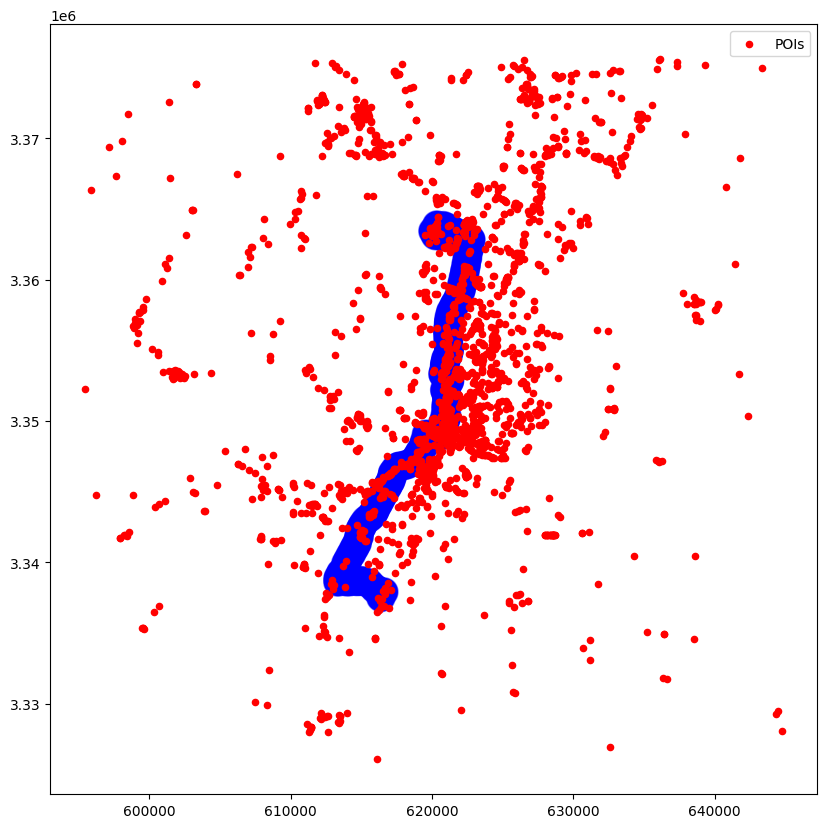

In [30]:
import matplotlib.pyplot as plt

# Plot the bus stops
ax = bus_stops_gdf.plot(figsize=(10, 10), color='blue', markersize=50, label='Bus Stops')

# Plot the buffered areas
bus_stops_gdf.set_geometry('geometry').plot(ax=ax, color='none', edgecolor='blue', alpha=0.5, label='500m Buffer')

# Plot the POIs
pois_gdf.plot(ax=ax, color='red', markersize=20, label='POIs')

# Plot the POIs within 500m
pois_within_500m.plot(ax=ax, color='green', markersize=50, label='POIs within 500m')

# Add a legend
ax.legend()

# Show the plot
plt.show()

In [19]:
bus_stops_gdf

,trip_id,arrival_time,departure_time,stop_id,stop_sequence,pickup_type,drop_off_type,shape_dist_traveled,timepoint,direction_id,stop_name,stop_lat,stop_lon,geometry,buffered_geometry
0,2729133_3220,04:58:00,04:58:00,5263,1,0,0,0.0000,1,1,200 Turk/Cullen,30.163367,-97.791351,POINT (616384.297 3337504.83),"POLYGON ((616884.297 3337504.83, 616881.889 33..."
1,2729133_3220,04:59:41,04:59:41,6479,2,0,0,0.4377,0,1,305 Slaughter/Alice Mae,30.167797,-97.793350,POINT (616186.597 3337993.738),"POLYGON ((616686.597 3337993.738, 616684.189 3..."
2,2729133_3220,05:00:27,05:00:27,5968,3,0,0,0.6388,0,1,324 Slaughter/Francia,30.169519,-97.795847,POINT (615944.131 3338182.032),"POLYGON ((616444.131 3338182.032, 616441.723 3..."
3,2729133_3220,05:01:43,05:01:43,6407,4,0,0,0.9725,0,1,603 Slaughter/1st,30.172829,-97.799722,POINT (615567.129 3338544.922),"POLYGON ((616067.129 3338544.922, 616064.721 3..."
4,2729133_3220,05:02:55,05:02:55,5416,5,0,0,1.2864,0,1,Slaughter/Simonetti,30.174173,-97.804467,POINT (615108.668 3338689.066),"POLYGON ((615608.668 3338689.066, 615606.26 33..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,2729077_3326,06:28:41,06:28:41,3767,90,0,0,22.0309,0,0,815 Slaughter/Palace,30.173859,-97.805997,POINT (614961.71 3338652.723),"POLYGON ((615461.71 3338652.723, 615459.302 33..."
185,2729077_3326,06:30:20,06:30:20,5999,91,0,0,22.5106,0,0,509 Slaughter/1st,30.171795,-97.798989,POINT (615638.917 3338431.074),"POLYGON ((616138.917 3338431.074, 616136.51 33..."
186,2729077_3326,06:31:19,06:31:19,5380,92,0,0,22.7985,0,0,404 Slaughter/Francia,30.168969,-97.795672,POINT (615961.626 3338121.258),"POLYGON ((616461.626 3338121.258, 616459.218 3..."
187,2729077_3326,06:32:03,06:32:03,5623,93,0,0,23.0095,0,0,236 Slaughter/Alice Mae,30.167354,-97.792824,POINT (616237.768 3337945.179),"POLYGON ((616737.768 3337945.179, 616735.36 33..."


In [ ]:
pois_within_500m = gpd.sjoin(pois_gdf, bus_stops_gdf, how='inner', predicate='intersects')

## Data Loading to GCS

In [8]:
filtered_pois_df.to_csv('filtered_pois.csv', index=False)
